In [87]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [88]:
df=pd.read_csv('dataset.csv')
df.head()

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,4 color printing special request additional in...
4,spam,do not have money get software cds from here s...


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20348 entries, 0 to 20347
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text_type  20348 non-null  object
 1   text       20348 non-null  object
dtypes: object(2)
memory usage: 318.1+ KB


In [90]:
##Handle Missing & Duplicated Values

In [91]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_report = pd.DataFrame({
'Missing Count' : missing,
'Missing %'     : missing_pct
}).query('`Missing Count` > 0')

print("Missing Values:")
print(quality_report.to_string())
print(f"Duplicate rows: {df.duplicated().sum()}")

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
Duplicate rows: 14


In [92]:
# remove Duplicate rows
df.drop_duplicates(inplace=True)
print(f"Duplicate rows after removal: {df.duplicated().sum()}")

Duplicate rows after removal: 0


In [93]:
##Text Cleaning

In [94]:
Words_dict = {
    'u': 'you',
    'ur': 'your',
    'r': 'are',
    '4u': 'for you',
    'gr8': 'great',
    'b4': 'before',
    'plz': 'please',
    'msg': 'message',
    'txt': 'text',
}

def replace_words(text):
    text = text.lower()
    words = text.split()
    new_words = [Words_dict.get(word, word) for word in words]
    return " ".join(new_words)

df['text'] = df['text'].apply(replace_words)

In [95]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'(http|https):\/\/[\w\-]+(\.[\w\-]+)+([\w\-\.,@?^=%&:/~\+#]*[\w\-\@?^=%&/~\+#])?', ' <url> ', text)

    text = re.sub(r'£|\$|€', ' <cur> ', text)
    text = re.sub(r'\b\d+\b', ' <num> ', text)

    text = re.sub(r'[^a-z\s<>]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['text'] = df['text'].apply(clean_text)
df.head()

,text_type,text
0,spam,naturally irresistible your corporate identity...
1,spam,the stock trading gunslinger fanny is merrill ...
2,spam,unbelievable new homes made easy im wanting to...
3,spam,<num> color printing special request additiona...
4,spam,do not have money get software cds from here s...


<Axes: xlabel='text_type'>

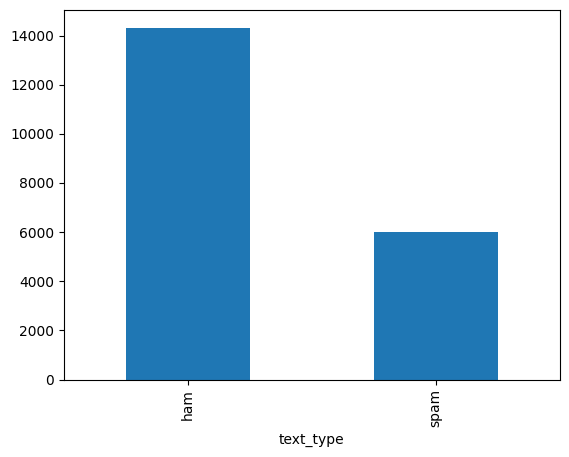

In [96]:
df['text_type'].value_counts().plot(kind='bar')

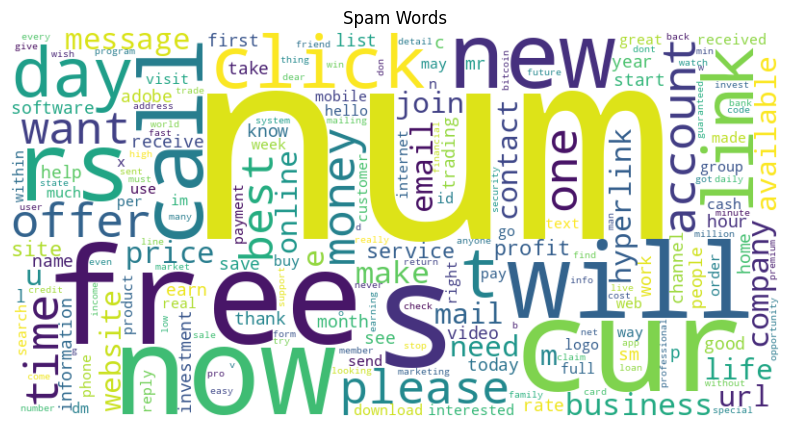

In [97]:
spam_text = " ".join(df[df['text_type'] == 'spam']['text'])

wordcloud_spam = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(spam_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_spam, interpolation='bilinear')
plt.title("Spam Words")
plt.axis("off")
plt.show()

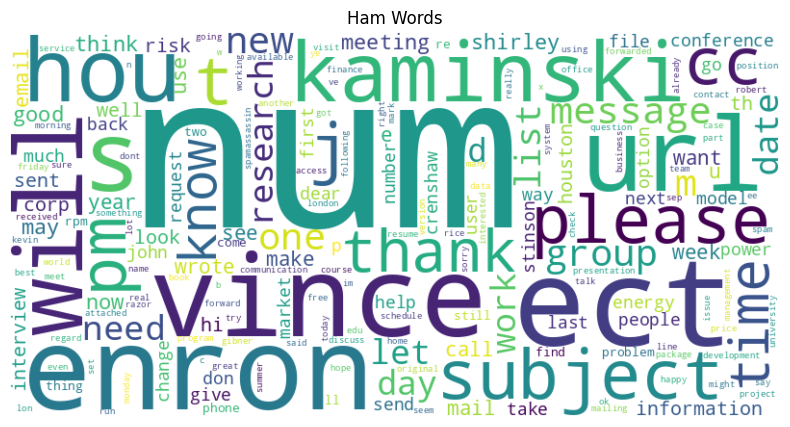

In [98]:
ham_text = " ".join(df[df['text_type'] == 'ham']['text'])

wordcloud_ham = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(ham_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_ham, interpolation='bilinear')
plt.title("Ham Words")
plt.axis("off")
plt.show()

In [99]:
##Preprocessing

In [100]:
# Import required libraries

import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt

from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

In [101]:
# Download NLTK resources

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [102]:
import re

def custom_tokenize(text):

    pattern = r'<num>|<url>|<cur>|[\w]+'
    tokens = re.findall(pattern, text)
    return tokens

In [103]:
df['tokens'] = df['text'].apply(custom_tokenize)

In [104]:
# Remove common stopwords

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [105]:
import re

def is_special_token(word):
    return (
        re.match(r'^https?://', word) or      # URL
        re.match(r'^\S+@\S+\.\S+$', word) or  # Email
        word.isdigit()                        # Numbers
    )

In [106]:
# Apply stemming

from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df['stemmed_tokens'] = df['tokens'].apply(
    lambda words: [
        stemmer.stem(word) if not is_special_token(word) else word
        for word in words
    ]
)

In [107]:
# Apply lemmatization

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['lemmatized_tokens'] = df['tokens'].apply(
    lambda words: [
        lemmatizer.lemmatize(word)
        if not is_special_token(word) else word
        for word in words
    ]
)

In [108]:
# Compare stemming vs lemmatization side by side

comparison_df = pd.DataFrame({
    "original": df['tokens'].explode(),
    "stemmed": df['stemmed_tokens'].explode(),
    "lemmatized": df['lemmatized_tokens'].explode()
})

comparison_df.head(200)

,original,stemmed,lemmatized
0,naturally,natur,naturally
0,irresistible,irresist,irresistible
0,corporate,corpor,corporate
0,identity,ident,identity
0,lt,lt,lt
...,...,...,...
3,pdf,pdf,pdf
3,format,format,format
3,phone,phone,phone
3,<num>,<num>,<num>


In [109]:
# Calculate unique vocabulary size

original_vocab = len(set(df['tokens'].explode()))
stemmed_vocab = len(set(df['stemmed_tokens'].explode()))
lemmatized_vocab = len(set(df['lemmatized_tokens'].explode()))

print("Original Vocabulary Size:", original_vocab)
print("Stemmed Vocabulary Size:", stemmed_vocab)
print("Lemmatized Vocabulary Size:", lemmatized_vocab)

Original Vocabulary Size: 47362
Stemmed Vocabulary Size: 37763
Lemmatized Vocabulary Size: 44153


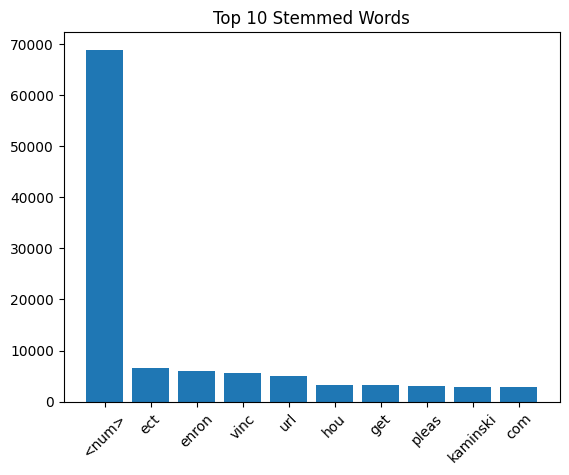

In [110]:
# Plot top 10 frequent stemmed words

from collections import Counter
import matplotlib.pyplot as plt

stem_words = df['stemmed_tokens'].explode()
stem_counts = Counter(stem_words)
top_stem = stem_counts.most_common(10)

words, counts = zip(*top_stem)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Stemmed Words")
plt.show()

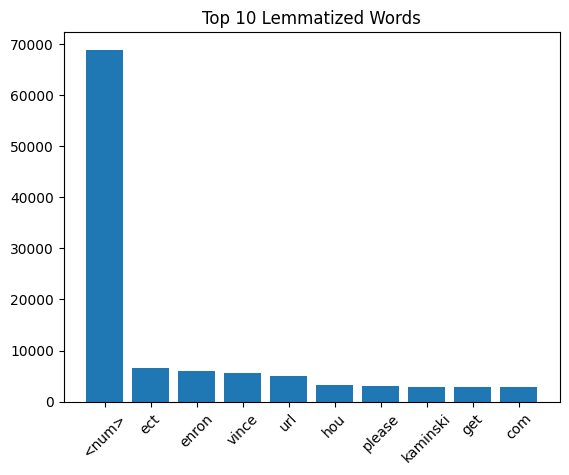

In [111]:
# Plot top 10 frequent lemmatized words

lemma_words = df['lemmatized_tokens'].explode()
lemma_counts = Counter(lemma_words)
top_lemma = lemma_counts.most_common(10)

words, counts = zip(*top_lemma)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 10 Lemmatized Words")
plt.show()

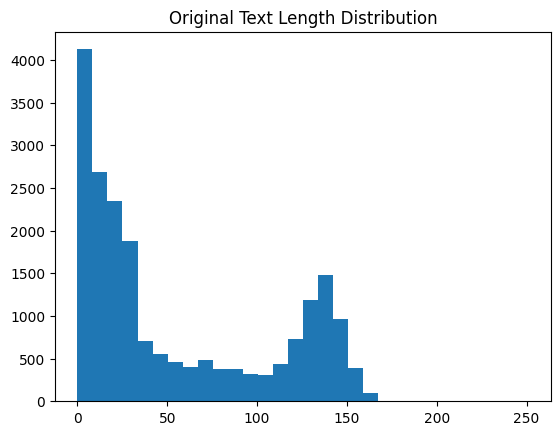

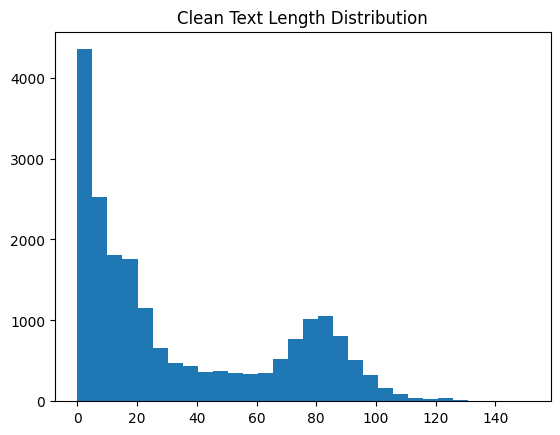

In [112]:
# Join lemmatized tokens into final clean text
df['clean_text'] = df['lemmatized_tokens'].apply(
    lambda words: " ".join(words)
)

# Compare message length before and after preprocessing

df['original_length'] = df['text'].str.split().apply(len)
df['clean_length'] = df['clean_text'].str.split().apply(len)

import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['original_length'], bins=30)
plt.title("Original Text Length Distribution")
plt.show()

plt.figure()
plt.hist(df['clean_length'], bins=30)
plt.title("Clean Text Length Distribution")
plt.show()

In [113]:
# Join lemmatized tokens into final clean text

df['clean_text'] = df['lemmatized_tokens'].apply(
    lambda words: " ".join(words)
)

In [114]:
##TF-IDF (Unigrams)

In [115]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)
X1 = tfidf.fit_transform(df['clean_text'])

In [116]:
print(X1.shape)
print(tfidf.get_feature_names_out()[:20])

(20334, 3000)
['aa' 'aap' 'ab' 'ability' 'able' 'absolutely' 'abstract' 'abt' 'ac'
 'academic' 'accept' 'accepted' 'access' 'according' 'account'
 'accounting' 'accurate' 'achieve' 'acrobat' 'across']


In [117]:
import pandas as pd

df_tfidf = pd.DataFrame(
    X1.toarray(),
    columns=tfidf.get_feature_names_out()
)

df_tfidf.head(10)

,aa,aap,ab,ability,able,absolutely,abstract,abt,ac,academic,...,young,youre,youtube,yr,yup,ze,zero,zhang,zimin,zip
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.239777,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [118]:
print("Non-zero values:", (X1 != 0).sum())
print("Total values:", X1.shape[0] * X1.shape[1])
print("Non-zero ratio:", ((X1 != 0).sum())/(X1.shape[0] * X1.shape[1]))

Non-zero values: 395247
Total values: 61002000
Non-zero ratio: 0.006479246582079276


In [119]:
import numpy as np

sparsity = np.mean(X1.toarray() == 0)
print("Sparsity:", sparsity)

Sparsity: 0.9935207534179207


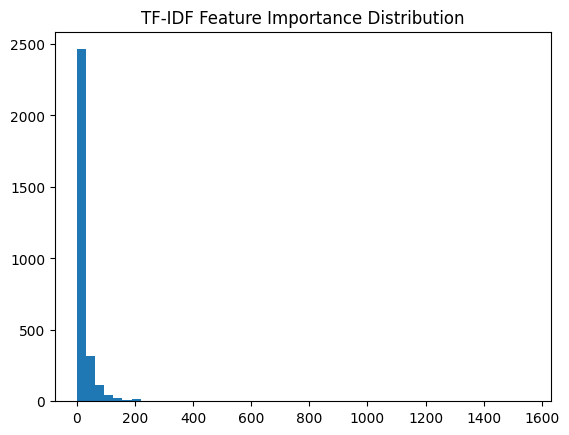

In [120]:
import matplotlib.pyplot as plt

plt.hist(np.sum(X1.toarray(), axis=0), bins=50)
plt.title("TF-IDF Feature Importance Distribution")
plt.show()

In [121]:
##Count Vectorizer (Unigrams)

In [122]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(
    max_features=3000,
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.90
)
X2 = count_vec.fit_transform(df['clean_text'])

In [123]:
print(X2.shape)
print(count_vec.get_feature_names_out()[:20])

(20334, 3000)
['aa' 'aap' 'ab' 'ability' 'able' 'absolutely' 'abstract' 'abt' 'ac'
 'academic' 'accept' 'accepted' 'access' 'according' 'account'
 'accounting' 'accurate' 'achieve' 'acrobat' 'across']


In [124]:
import pandas as pd

df_count = pd.DataFrame(
    X2.toarray(),
    columns=count_vec.get_feature_names_out()
)

df_count.head(10)

,aa,aap,ab,ability,able,absolutely,abstract,abt,ac,academic,...,young,youre,youtube,yr,yup,ze,zero,zhang,zimin,zip
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [125]:
print("Non-zero values:", (X2 != 0).sum())
print("Total values:", X2.shape[0] * X2.shape[1])
print("Non-zero ratio:", ((X2 != 0).sum())/(X2.shape[0] * X2.shape[1]))

Non-zero values: 395247
Total values: 61002000
Non-zero ratio: 0.006479246582079276


In [126]:
import numpy as np

sparsity_count = np.mean(X2.toarray() == 0)
print("Count Vectorizer Sparsity:", sparsity_count)

Count Vectorizer Sparsity: 0.9935207534179207


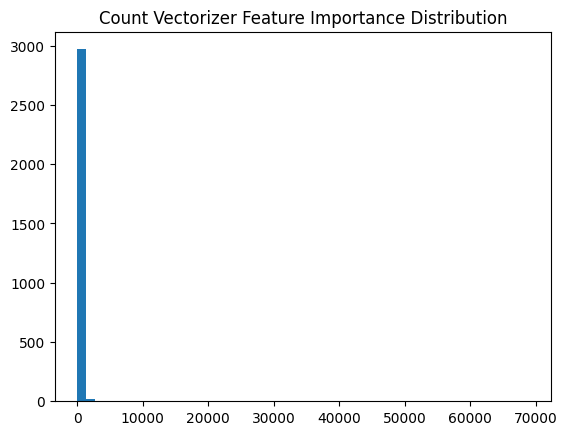

In [127]:
import matplotlib.pyplot as plt

plt.hist(np.sum(X2.toarray(), axis=0), bins=50)
plt.title("Count Vectorizer Feature Importance Distribution")
plt.show()

In [128]:
##Character n-grams

In [129]:
char_features = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 4),
    max_features=2000,
    min_df=2,
    max_df=0.90
)
X3 = char_features.fit_transform(df['clean_text'])

In [130]:
print(X3.shape)
print(char_features.get_feature_names_out()[:20])

(20334, 2000)
[' <' ' <c' ' <cu' ' <n' ' <nu' ' a' ' ac' ' acc' ' ad' ' add' ' ag' ' al'
 ' als' ' am' ' an' ' ap' ' app' ' ar' ' as' ' ass']


In [131]:
import pandas as pd

df_char = pd.DataFrame(
    X3.toarray(),
    columns=char_features.get_feature_names_out()
)

df_char.head(10)

,<,<c,<cu,<n,<nu,a,ac,acc,ad,add,...,ya,ye,yea,year,yi,yo,yp,ys,yt,ze
0,0.000000,0.0,0.0,0.000000,0.000000,0.020881,0.000000,0.000000,0.000000,0.00000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.023391,0.0,0.000000
1,0.000000,0.0,0.0,0.000000,0.000000,0.042939,0.000000,0.000000,0.000000,0.00000,...,0.0,0.080668,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
2,0.094772,0.0,0.0,0.094879,0.094879,0.072882,0.000000,0.000000,0.036605,0.00000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
3,0.097879,0.0,0.0,0.097990,0.097990,0.047045,0.000000,0.000000,0.070885,0.05713,...,0.0,0.000000,0.0,0.0,0.0,0.026952,0.0,0.000000,0.0,0.000000
4,0.000000,0.0,0.0,0.000000,0.000000,0.033756,0.000000,0.000000,0.000000,0.00000,...,0.0,0.063416,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
5,0.052091,0.0,0.0,0.052150,0.052150,0.066766,0.033470,0.000000,0.000000,0.00000,...,0.0,0.000000,0.0,0.0,0.0,0.038250,0.0,0.000000,0.0,0.040949
6,0.040042,0.0,0.0,0.040088,0.040088,0.019246,0.019296,0.022627,0.000000,0.00000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.021560,0.0,0.000000
7,0.045096,0.0,0.0,0.045148,0.045148,0.043350,0.000000,0.000000,0.043546,0.00000,...,0.0,0.040720,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000
8,0.208644,0.0,0.0,0.208881,0.208881,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.022366
9,0.045230,0.0,0.0,0.045282,0.045282,0.043479,0.000000,0.000000,0.043675,0.00000,...,0.0,0.040841,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000


In [132]:
print("Non-zero values:", (X3 != 0).sum())
print("Total values:", X3.shape[0] * X3.shape[1])
print("Non-zero ratio:", ((X3 != 0).sum())/(X3.shape[0] * X3.shape[1]))

Non-zero values: 5029678
Total values: 40668000
Non-zero ratio: 0.1236765515884725


In [133]:
import numpy as np

sparsity_char = np.mean(X3.toarray() == 0)
print("Char N-grams Sparsity:", sparsity_char)

Char N-grams Sparsity: 0.8763234484115275


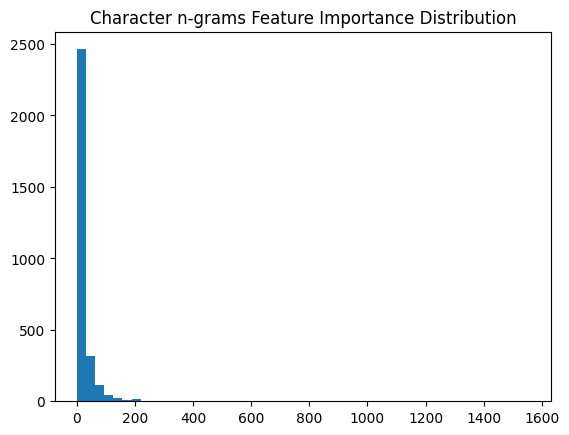

In [134]:
import matplotlib.pyplot as plt

plt.hist(np.sum(X1.toarray(), axis=0), bins=50)
plt.title("Character n-grams Feature Importance Distribution")
plt.show()

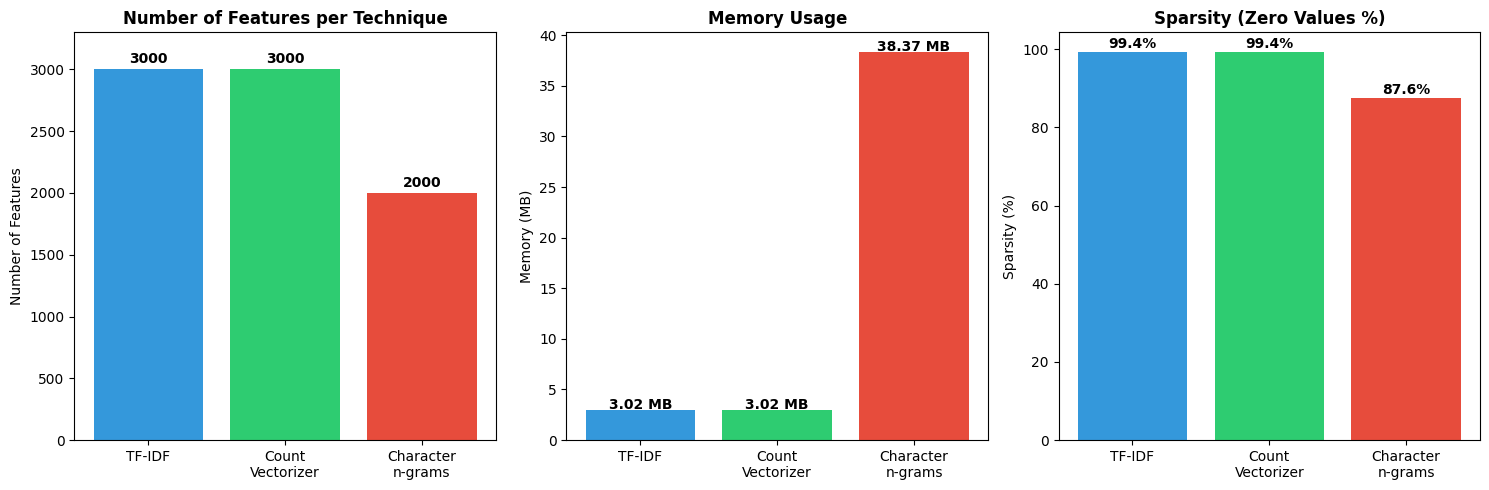

In [135]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Number of Features
techniques = ['TF-IDF', 'Count\nVectorizer', 'Character\nn-grams']
features_count = [X1.shape[1], X2.shape[1], X3.shape[1]]
axes[0].bar(techniques, features_count, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[0].set_title('Number of Features per Technique', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Features')
axes[0].set_ylim(0, max(features_count) * 1.1)
for i, v in enumerate(features_count):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 2: Memory Usage
memory_usage = [
    X1.data.nbytes / 1024 / 1024,
    X2.data.nbytes / 1024 / 1024,
    X3.data.nbytes / 1024 / 1024
]
axes[1].bar(techniques, memory_usage, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[1].set_title('Memory Usage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Memory (MB)')
for i, v in enumerate(memory_usage):
    axes[1].text(i, v + 0.1, f'{v:.2f} MB', ha='center', fontweight='bold')

# Plot 3: Sparsity
sparsity = [
    (1 - X1.nnz / (X1.shape[0] * X1.shape[1])) * 100,
    (1 - X2.nnz / (X2.shape[0] * X2.shape[1])) * 100,
    (1 - X3.nnz / (X3.shape[0] * X3.shape[1])) * 100
]
axes[2].bar(techniques, sparsity, color=['#3498db', '#2ecc71', '#e74c3c'])
axes[2].set_title('Sparsity (Zero Values %)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Sparsity (%)')
for i, v in enumerate(sparsity):
    axes[2].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [136]:
##POS TAG FEATURES (part of speech)

In [137]:
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize

def get_pos_features(text):
    tokens = word_tokenize(text)
    tags = pos_tag(tokens)

    noun = sum(1 for w, t in tags if t.startswith('NN'))
    verb = sum(1 for w, t in tags if t.startswith('VB'))
    adj = sum(1 for w, t in tags if t.startswith('JJ'))

    return [noun, verb, adj]

X4 = np.array(df['clean_text'].apply(get_pos_features).tolist())

In [138]:
##LENGTH-BASED FEATURES

In [139]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean_text'].apply(len)
df['digit_count'] = df['clean_text'].apply(lambda x: sum(c.isdigit() for c in x))
df['url_count'] = df['clean_text'].apply(lambda x: x.count(''))

X5 = df[['word_count', 'char_count', 'digit_count', 'url_count']].values

In [140]:
##Repetition Score & Unique Ratio

In [141]:
import numpy as np
from collections import Counter

def repetition_score(text):
    words = text.split()
    if len(words) == 0:
        return 0
    counts = Counter(words)
    return max(counts.values()) / len(words)

df['repetition_score'] = df['clean_text'].apply(repetition_score)


def unique_ratio(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df['unique_ratio'] = df['clean_text'].apply(unique_ratio)
# Combine Features

X6 = df[['repetition_score', 'unique_ratio']].values

In [142]:
print("HANDCRAFTED FEATURE ENGINEERING")
print()

print(f"{'Technique':<25} {'Samples':<10} {'Features':<10}")
print(f"{'Length-based':<25} {X5.shape[0]:<10} {X5.shape[1]:<10}")
print(f"{'POS tagging':<25} {X4.shape[0]:<10} {X4.shape[1]:<10}")
print("BEHAVIORAL FEATURE ENGINEERING")
print()
print(f"{'Technique':<25} {'Samples':<10} {'Features':<10}")
print(f"{'Repetition + Unique':<25} {X6.shape[0]:<10} {X6.shape[1]:<10}")

HANDCRAFTED FEATURE ENGINEERING

Technique                 Samples    Features  
Length-based              20334      4         
POS tagging               20334      3         
BEHAVIORAL FEATURE ENGINEERING

Technique                 Samples    Features  
Repetition + Unique       20334      2         


In [143]:
import pandas as pd

print("\n FEATURE EXAMPLES")

# Length features sample
print("\n Length-based Features Sample:")
print(pd.DataFrame(X5, columns=['word_count','char_count','digit_count','url_count']).head())

# POS features sample
print("\n POS Features Sample:")
print(pd.DataFrame(X4, columns=['noun','verb','adj']).head())

#Repition and Unique
print("\n Behavioral Features Sample:")
print(pd.DataFrame(X6, columns=['repetition_score','unique_ratio']).head())


 FEATURE EXAMPLES

 Length-based Features Sample:
   word_count  char_count  digit_count  url_count
0          75         591            0        592
1          63         497            0        498
2          44         298            0        299
3          54         379            0        380
4          18         120            0        121

 POS Features Sample:
   noun  verb  adj
0    37     8   23
1    33    12   15
2    35     8    9
3    56     4   10
4    10     2    4

 Behavioral Features Sample:
   repetition_score  unique_ratio
0          0.040000      0.866667
1          0.047619      0.904762
2          0.113636      0.886364
3          0.166667      0.574074
4          0.111111      0.944444


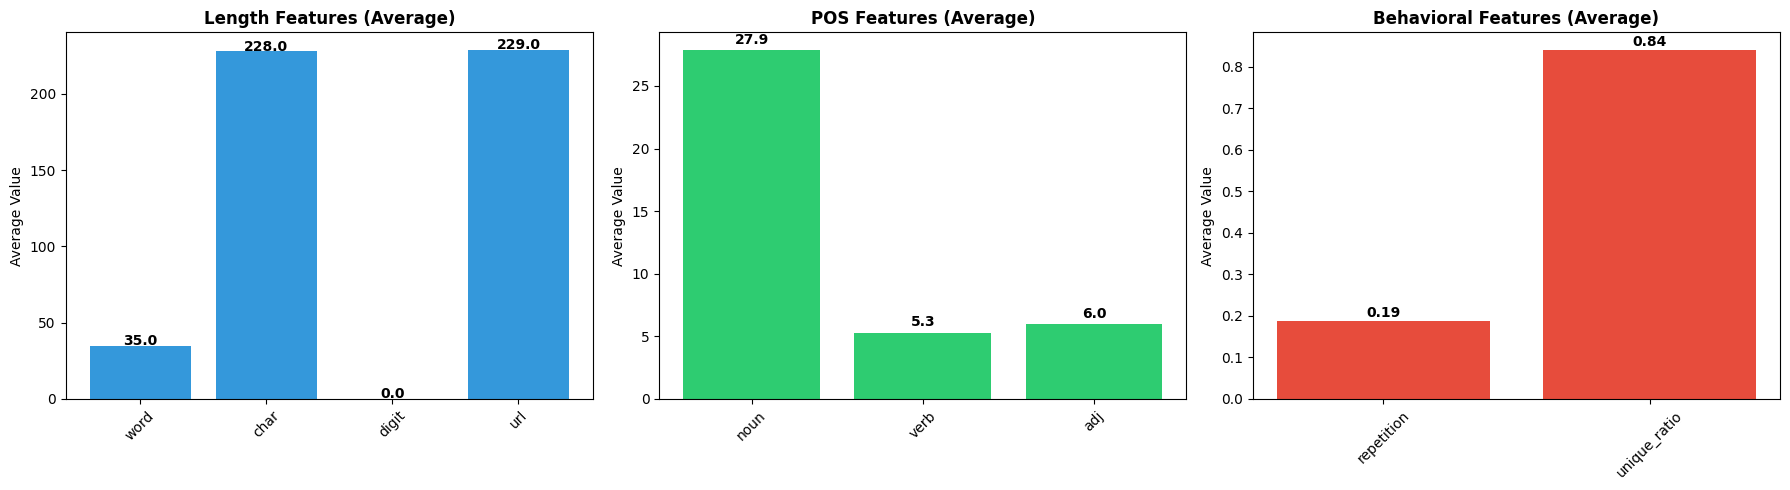

In [144]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Length Features

length_labels = ['word', 'char', 'digit', 'url']
length_values = X5.mean(axis=0)

axes[0].bar(length_labels, length_values, color='#3498db')
axes[0].set_title('Length Features (Average)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Value')
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(length_values):
    axes[0].text(i, v + 0.5, f"{v:.1f}", ha='center', fontweight='bold')

# POS Features

pos_labels = ['noun', 'verb', 'adj']
pos_values = X4.mean(axis=0)

axes[1].bar(pos_labels, pos_values, color='#2ecc71')
axes[1].set_title('POS Features (Average)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Value')
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(pos_values):
    axes[1].text(i, v + 0.5, f"{v:.1f}", ha='center', fontweight='bold')

# Behavioral Features

beh_labels = ['repetition', 'unique_ratio']
beh_values = X6.mean(axis=0)

axes[2].bar(beh_labels, beh_values, color='#e74c3c')
axes[2].set_title('Behavioral Features (Average)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Average Value')
axes[2].tick_params(axis='x', rotation=45)

for i, v in enumerate(beh_values):
    axes[2].text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')


plt.tight_layout()
plt.show()

In [145]:
# Text representations
X_text = {
    "TF-IDF": X1,
    "Count": X2,
    "Char": X3,
    "POS": X4,
    "Meta": X5,
    "Behavior": X6
}

In [146]:
print(df['text_type'].value_counts())

text_type
ham     14323
spam     6011
Name: count, dtype: int64


In [147]:
df['text_type'] = df['text_type'].map({'ham': 0, 'spam': 1})
y = df['text_type']

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def evaluate(X, y, name):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(
        max_iter=2000,
        solver='liblinear'
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print(f"{name} Accuracy: {acc:.4f}")
    return acc

In [149]:
scores = {}

scores["TF-IDF"] = evaluate(X1, y, "TF-IDF")
scores["Count"] = evaluate(X2, y, "Count")
scores["Char"] = evaluate(X3, y, "Char")
scores["POS"] = evaluate(X4, y, "POS")
scores["Meta"] = evaluate(X5, y, "Meta")
scores["Behavior"] = evaluate(X6, y, "Behavior")

TF-IDF Accuracy: 0.9329
Count Accuracy: 0.9378
Char Accuracy: 0.9019
POS Accuracy: 0.7045
Meta Accuracy: 0.7045
Behavior Accuracy: 0.7081


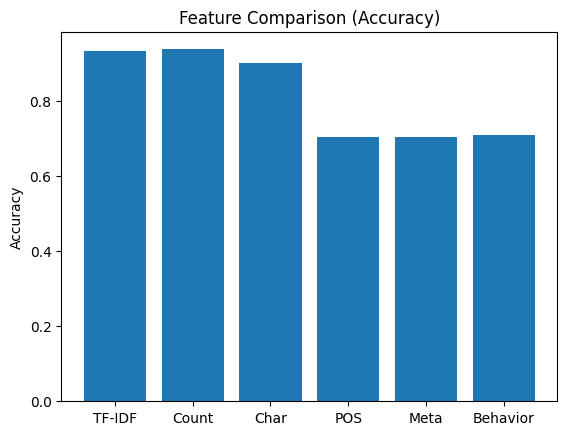

In [150]:
import matplotlib.pyplot as plt

plt.bar(scores.keys(), scores.values())
plt.title("Feature Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.show()

In [151]:
best_feature = max(scores, key=scores.get)
print("Best Feature:", best_feature)

Best Feature: Count


In [152]:
from scipy.sparse import hstack

final = hstack([X2, X1, X3])